<a href="https://colab.research.google.com/github/Shinkun-git/GroupProject/blob/main/Prashant_38.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Name : Prashant Kumar Sinku
# Roll No. 38
# Network Science

# 1. Adding required files


In [ ]:
# Mounts Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [ ]:
# Set directory to listed path
%cd /content/drive/My Drive/Prashant_38/Dependencies

/content/drive/My Drive/Prashant_38/Dependencies


# Cleating Text (removing stop words ,special character e.t.c)

In [ ]:
import re

import nltk
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
nltk.download('stopwords')
nltk.download('wordnet')

# Initialize the lemmatizer
lemmatizer = WordNetLemmatizer()

# Get English stopwords from NLTK
stop_words = set(stopwords.words('english'))


def clean_text(text):
    # 1. Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)

    # 2. Remove mentions and hashtags
    text = re.sub(r'\@\w+|\#', '', text)

    # 3. Remove special characters and numbers
    text = re.sub(r"[^a-zA-Z\s]", '', text)

    # 4. Convert text to lowercase
    text = text.lower()

    # 5. Tokenize the text
    words = text.split()

    # 6. Remove stopwords using NLTK's stopwords list
    filtered_words = [word for word in words if word not in stop_words]

    # 7. Lemmatize each word
    lemmatized_words = [lemmatizer.lemmatize(word) for word in filtered_words]

    # 8. Rejoin the words into cleaned text
    cleaned_text = ' '.join(lemmatized_words)

    return cleaned_text

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


# Counting frequency of word in the given cleaned text

In [ ]:

def frequency_count(text):
    words = text.split()
    word_frequency = {}

    for word in words:
        if word in word_frequency:
            word_frequency[word] += 1
        else:
            word_frequency[word] = 1

    return word_frequency

# Displying frequency of top 50 words in the text

In [ ]:
import matplotlib.pyplot as plt

def plot_all_word_frequencies(word_counts,chaptercount):
    # Sort the dictionary by frequency in descending order
    sorted_word_counts = sorted(word_counts.items(), key=lambda x: x[1], reverse=True)

    # Get the top 20 words and their frequencies
    top_50 = sorted_word_counts[:50]

    # Extract words and frequencies
    words, frequencies = zip(*top_50)

    # Create a vertical bar graph
    plt.figure(figsize=(20, 8))
    plt.bar(words, frequencies, color='skyblue')

    # Add titles and labels
    plt.title(f"Top 50 Word Frequencies from chapter {chaptercount}")
    plt.xlabel('Words')
    plt.ylabel('Frequency')

    # Rotate x-axis labels for readability
    plt.xticks(rotation=45, ha='right')

    # Adjust layout
    plt.tight_layout()
    plt.show()

# Graph Visualization function With 20 node for each chapter and edge weight showing common words between those chapter

In [ ]:
pip install pyvis


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

def visualize_graph_from_adj_matrix(adj_matrix, node_color='skyblue', edge_color='gray', edge_label_color='red'):

    # Check if input is a square matrix
    if adj_matrix.ndim != 2:
        raise ValueError("Adjacency matrix must be square (N x N).")

    # Create a graph from the adjacency matrix
    G = nx.from_numpy_array(adj_matrix)

    # Set up the figure for visualization with more space
    plt.figure(figsize=(15, 12))  # Increase the figure size for better clarity

    # Generate positions for nodes using Kamada-Kawai layout (better for large graphs)
    pos = nx.kamada_kawai_layout(G, weight='weight')

    # Draw nodes with larger size and black borders for better contrast
    nx.draw_networkx_nodes(
        G,
        pos,
        node_color=node_color,
        node_size=1200,  # Increase node size for better visibility
        edgecolors='black',  # Add a border to nodes
        linewidths=1.5
    )

    # Draw edges with specified color and adjusted transparency for clarity
    nx.draw_networkx_edges(
        G,
        pos,
        edge_color=edge_color,
        width=3,
        alpha=0.7  # Reduce transparency for better edge visibility
    )

    # Draw node labels with larger font size and bold for readability
    nx.draw_networkx_labels(
        G,
        pos,
        font_size=16,
        font_color='black',
        font_weight='bold'
    )

    # Add edge labels (weights) with larger font and red color for distinction
    edge_labels = nx.get_edge_attributes(G, "weight")
    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=edge_labels,
        font_color=edge_label_color,
        font_size=12,
        font_weight='bold'
    )

    # Add title and remove axes for a cleaner presentation
    plt.title("Graph Representation of the Adjacency Matrix", fontsize=20, fontweight='bold')
    plt.axis('off')

    # Show the plot
    plt.tight_layout()
    plt.show()


# Extracting chapter from book and converting it into a text

In [ ]:
pip install pymupdf

In [ ]:


import fitz  # PyMuPDF

def extract_chapter(pdf_path, chapter_start_page, chapter_end_page, output_path):
    """
    Extracts text from a specified range of pages in a PDF file and saves it to a text file.

    Args:
        pdf_path (str): Path to the input PDF file.
        chapter_start_page (int): The starting page number of the chapter (0-based).
        chapter_end_page (int): The ending page number of the chapter (0-based).
        output_path (str): Path to save the extracted text file.
    """
    try:
        # Open the PDF file
        document = fitz.open(pdf_path)
        extracted_text = ""

        # Iterate through the specified page range
        for page_num in range(chapter_start_page, chapter_end_page + 1):
            page = document[page_num]
            extracted_text += page.get_text()

        # Save the extracted text to the output file
        with open(output_path, "w", encoding="utf-8") as output_file:
            output_file.write(extracted_text)

        print(f"Chapter text successfully saved to {output_path}")

    except Exception as e:
        print(f"An error occurred: {e}")

# Example usage:
# extract_chapter("PressmanBook 7th edition.pdf", 95, 118, "chapter4.txt")


In [ ]:
extract_chapter("/content/drive/My Drive/Prashant_38/Dependencies/book.pdf", 30, 55, "ch1.txt")
extract_chapter("book.pdf", 59, 92, "ch2.txt")
extract_chapter("book.pdf", 94, 122, "ch3.txt")
extract_chapter("book.pdf", 124, 145, "ch4.txt")
extract_chapter("book.pdf", 147, 175, "ch5.txt")
extract_chapter("book.pdf", 177, 213, "ch6.txt")
extract_chapter("book.pdf", 215, 243, "ch7.txt")
extract_chapter("book.pdf", 244, 269, "ch8.txt")
extract_chapter("book.pdf", 271, 303, "ch9.txt")
extract_chapter("book.pdf", 305, 340, "ch10.txt")
extract_chapter("book.pdf", 341, 374, "ch11.txt")
extract_chapter("book.pdf", 376, 400, "ch12.txt")
extract_chapter("book.pdf", 402, 423, "ch13.txt")
extract_chapter("book.pdf", 426, 443, "ch14.txt")
extract_chapter("book.pdf", 445, 460, "ch15.txt")
extract_chapter("book.pdf", 461, 476, "ch16.txt")
extract_chapter("book.pdf", 478, 507, "ch17.txt")
extract_chapter("book.pdf", 510, 539, "ch18.txt")
extract_chapter("book.pdf", 540, 556, "ch19.txt")
extract_chapter("book.pdf", 558, 583, "ch20.txt")

Chapter text successfully saved to ch1.txt
Chapter text successfully saved to ch2.txt
Chapter text successfully saved to ch3.txt
Chapter text successfully saved to ch4.txt
Chapter text successfully saved to ch5.txt
Chapter text successfully saved to ch6.txt
Chapter text successfully saved to ch7.txt
Chapter text successfully saved to ch8.txt
Chapter text successfully saved to ch9.txt
Chapter text successfully saved to ch10.txt
Chapter text successfully saved to ch11.txt
Chapter text successfully saved to ch12.txt
Chapter text successfully saved to ch13.txt
Chapter text successfully saved to ch14.txt
Chapter text successfully saved to ch15.txt
Chapter text successfully saved to ch16.txt
Chapter text successfully saved to ch17.txt
Chapter text successfully saved to ch18.txt
Chapter text successfully saved to ch19.txt
Chapter text successfully saved to ch20.txt


# Reading chapters and Printing chapter 1 and chapter 2 data

In [ ]:
ch1 = open('ch1.txt', encoding='utf-8').read()
ch2 = open('ch2.txt', encoding='utf-8').read()


In [ ]:
ch1

'I had to agree. “So, your life will be much simpler. You guys won’t have to worry\nabout five different versions of the same App in use across tens of thousands of\nusers.”\nHe smiled. “Absolutely. Only the most current version residing on our servers.\nWhen we make a change or a correction, we supply updated functionality and\ncontent to every user. Everyone has it instantly!”\nI grimaced. “But if you make a mistake, everyone has that instantly as well.”\nHe chuckled. “True, that’s why we’re redoubling our efforts to do even better\nsoftware engineering. Problem is, we have to do it ‘fast’ because the market has\naccelerated in every application area.”\nI leaned back and put my hands behind my head. “You know what they say, . . .\nyou can have it fast, you can have it right, or you can have it cheap. Pick two!”\n“I’ll take it fast and right,” he said as he began to get up.\nI stood as well. “Then you really do need software engineering.”\n“I know that,” he said as he began to move aw

In [ ]:
ch2

'CHAPTER 2\nPROCESS MODELS\n31\nBut what exactly is a software process from a technical point of view? Within the\ncontext of this book, I define a software process as a framework for the activities, ac-\ntions, and tasks that are required to build high-quality software. Is “process” syn-\nonymous with software engineering? The answer is “yes and no.” A software process\ndefines the approach that is taken as software is engineered. But software engi-\nneering also encompasses technologies that populate the process—technical meth-\nods and automated tools.\nMore important, software engineering is performed by creative, knowledgeable\npeople who should adapt a mature software process so that it is appropriate for the\nproducts that they build and the demands of their marketplace.\n2.1\nA GENERIC PROCESS MODEL\nIn Chapter 1, a process was defined as a collection of work activities, actions, and\ntasks that are performed when some work product is to be created. Each of these\nactivities, a

In [ ]:
ch3 = open('ch3.txt', encoding='utf-8').read()
ch4 = open('ch4.txt', encoding='utf-8').read()
ch5 = open('ch5.txt', encoding='utf-8').read()
ch6 = open('ch6.txt', encoding='utf-8').read()
ch7 = open('ch7.txt', encoding='utf-8').read()
ch8 = open('ch8.txt', encoding='utf-8').read()
ch9 = open('ch9.txt', encoding='utf-8').read()
ch10 = open('ch10.txt', encoding='utf-8').read()
ch11 = open('ch11.txt', encoding='utf-8').read()
ch12 = open('ch12.txt', encoding='utf-8').read()
ch13 = open('ch13.txt', encoding='utf-8').read()
ch14 = open('ch14.txt', encoding='utf-8').read()
ch15 = open('ch15.txt', encoding='utf-8').read()
ch16 = open('ch16.txt', encoding='utf-8').read()
ch17 = open('ch17.txt', encoding='utf-8').read()
ch18 = open('ch18.txt', encoding='utf-8').read()
ch19 = open('ch19.txt', encoding='utf-8').read()
ch20 = open('ch20.txt', encoding='utf-8').read()


# Calling text cleaning function

In [ ]:
ch1Words = clean_text(ch1)
ch2Words = clean_text(ch2)
ch3Words = clean_text(ch3)
ch4Words = clean_text(ch4)
ch5Words = clean_text(ch5)
ch6Wors = clean_text(ch6)
ch7Words = clean_text(ch7)
ch8Words = clean_text(ch8)
ch9Words = clean_text(ch9)
ch10Words = clean_text(ch10)
ch11Words = clean_text(ch11)
ch12Words = clean_text(ch12)
ch13Words = clean_text(ch13)
ch14Words = clean_text(ch14)
ch15Words = clean_text(ch15)
ch16Words = clean_text(ch16)
ch17Words = clean_text(ch17)
ch18Words = clean_text(ch18)
ch19Words = clean_text(ch19)
ch20Words = clean_text(ch20)


# Printing cleaned word from chapter 1 and chapter 2

In [ ]:
ch1Words

'agree life much simpler guy wont worry five different version app use across ten thousand user smiled absolutely current version residing server make change correction supply updated functionality content every user everyone instantly grimaced make mistake everyone instantly well chuckled true thats redoubling effort even better software engineering problem fast market accelerated every application area leaned back put hand behind head know say fast right cheap pick two ill take fast right said began get stood well really need software engineering know said began move away problem weve got convince still another generation techie true software really dead wouldnt reading book computer software continues single important technology world stage also prime example law unintended consequence fifty year ago one could predicted software would become indis pensable technology business science engineering software would enable creation new technology eg genetic engineering nanotech nology ext

In [ ]:
ch2Words

'chapter process model exactly software process technical point view within context book define software process framework activity ac tions task required build highquality software process syn onymous software engineering answer yes software process defines approach taken software engineered software engi neering also encompasses technology populate processtechnical meth od automated tool important software engineering performed creative knowledgeable people adapt mature software process appropriate product build demand marketplace generic process model chapter process defined collection work activity action task performed work product created activity action task reside within framework model defines relationship process one another software process represented schematically figure referring figure framework activity populated set software engineering action software engineering action defined task set identifies work task completed work product produced quality assurance point requi

# Storing frequency of words for each chapter

In [ ]:
chapters = [
   ch1Words,
  ch2Words,
  ch3Words,
  ch4Words,
  ch5Words,
  ch6Wors,
  ch7Words,
  ch8Words,
  ch9Words,
  ch10Words,
  ch11Words,
  ch12Words,
  ch13Words,
  ch14Words,
  ch15Words,
  ch16Words,
  ch17Words,
  ch18Words,
  ch19Words,
   ch20Words
]

word_freq_array = []
for i in range(1,21):
  word_freq_array.append(frequency_count(chapters[i-1]))


# Printing word frequency for chapter 1

In [ ]:
word_freq_array[0]

{'agree': 2,
 'life': 7,
 'much': 9,
 'simpler': 2,
 'guy': 1,
 'wont': 3,
 'worry': 1,
 'five': 7,
 'different': 16,
 'version': 4,
 'app': 1,
 'use': 13,
 'across': 5,
 'ten': 2,
 'thousand': 5,
 'user': 26,
 'smiled': 1,
 'absolutely': 1,
 'current': 2,
 'residing': 1,
 'server': 2,
 'make': 17,
 'change': 36,
 'correction': 1,
 'supply': 1,
 'updated': 2,
 'functionality': 6,
 'content': 12,
 'every': 13,
 'everyone': 2,
 'instantly': 2,
 'grimaced': 1,
 'mistake': 1,
 'well': 9,
 'chuckled': 1,
 'true': 7,
 'thats': 3,
 'redoubling': 1,
 'effort': 10,
 'even': 8,
 'better': 10,
 'software': 400,
 'engineering': 122,
 'problem': 30,
 'fast': 3,
 'market': 7,
 'accelerated': 1,
 'application': 52,
 'area': 7,
 'leaned': 1,
 'back': 1,
 'put': 3,
 'hand': 1,
 'behind': 4,
 'head': 1,
 'know': 9,
 'say': 4,
 'right': 7,
 'cheap': 1,
 'pick': 2,
 'two': 5,
 'ill': 3,
 'take': 11,
 'said': 3,
 'began': 2,
 'get': 9,
 'stood': 1,
 'really': 2,
 'need': 20,
 'move': 2,
 'away': 2,
 'weve'

# Plotting Word and frequency for each chapter in Bar Graph

KeyboardInterrupt: 

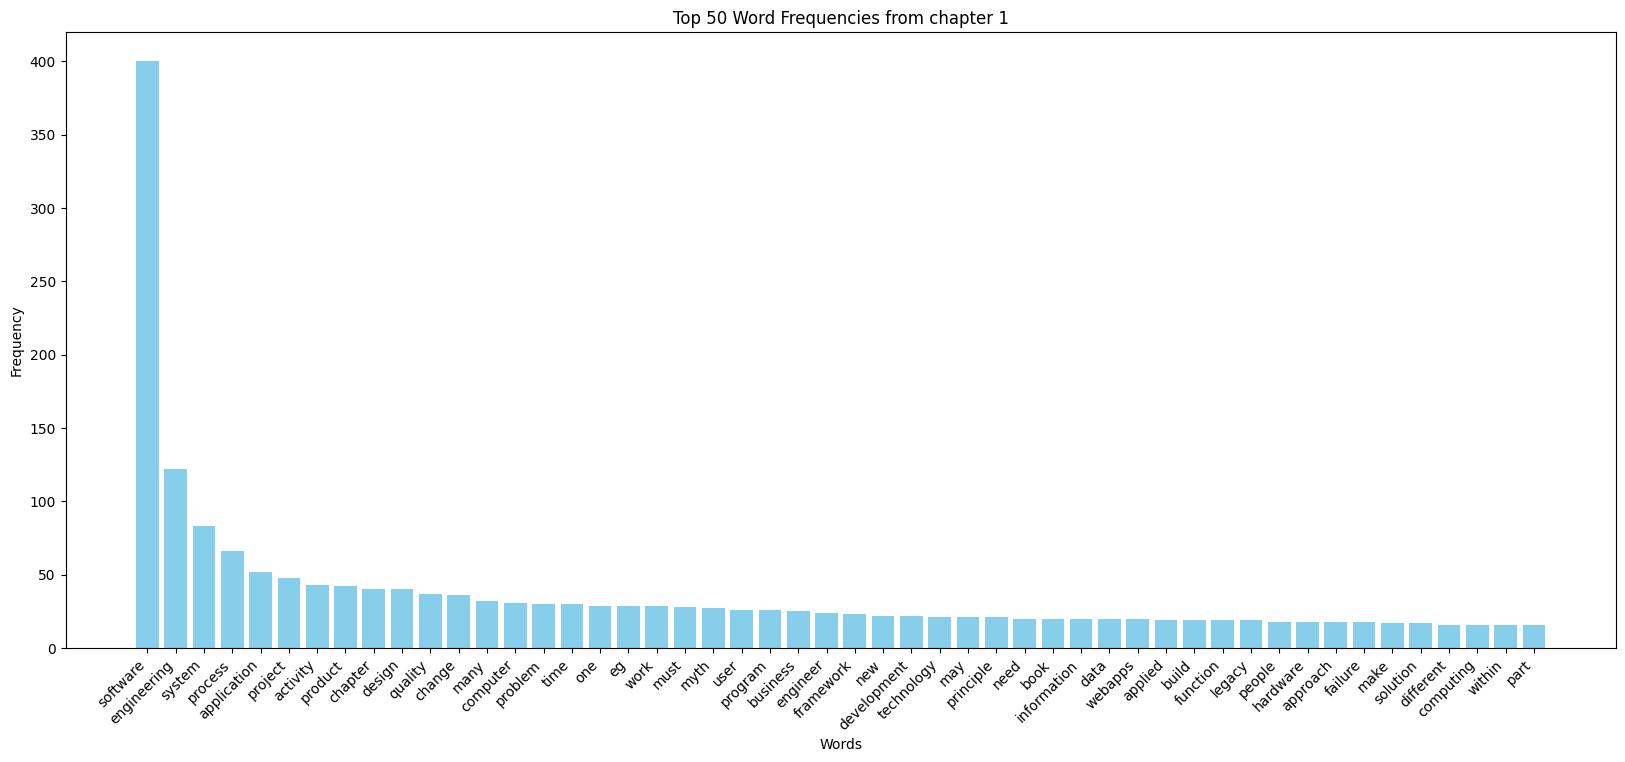

In [ ]:
for i in range(1,21):
  plot_all_word_frequencies(word_freq_array[i-1],i)

# Counting common word between two chapters

In [ ]:
def count_common_words(dict1, dict2):

    # Use set intersection to find common keys (words)
    common_words = set(dict1.keys()) & set(dict2.keys())
    return len(common_words)


# Printing common word between chapter 1 and chapter 2

In [ ]:
count_common_words(word_freq_array[0],word_freq_array[1])

# Creating adjcency matrix of common words

In [ ]:
def create_adjacency_matrix(word_freq_array):

    adjacency_matrix = []

    # Loop over each pair of word-frequency dictionaries and create the matrix
    for i in range(len(word_freq_array)):
        row = []
        for j in range(len(word_freq_array)):
            # Count common words between the i-th and j-th dictionaries
            common_word_count = count_common_words(word_freq_array[i], word_freq_array[j])
            row.append(common_word_count)
        adjacency_matrix.append(row)

    return np.array(adjacency_matrix)


# Printing Adjcency matrix

In [ ]:
adjacency_matrix = create_adjacency_matrix(word_freq_array)
adjacency_matrix

# Visualizing common words using Graph Data Structure

In [ ]:
visualize_graph_from_adj_matrix(np.array(adjacency_matrix))

# Visulizing common words using heat map

In [ ]:
import numpy as np
import plotly.express as px

def plot_interactive_heatmap_with_tooltip(adj_matrix):

    # Number of chapters
    num_chapters = len(adj_matrix)

    # Create the labels for the chapters
    chapters = [f'Ch{i+1}' for i in range(num_chapters)]

    # Create a hover text that will display the common words count
    hover_text = [[f"Common Words: {adj_matrix[i][j]}" for j in range(num_chapters)] for i in range(num_chapters)]

    # Create the heatmap using plotly
    fig = px.imshow(
        adj_matrix,
        labels={'x': 'Chapters', 'y': 'Chapters'},
        x=chapters,
        y=chapters,
        color_continuous_scale='Viridis',  # You can use other color scales
        title="Interactive Heatmap of Common Words Between Chapters",
        text_auto=True  # This will show the text in each cell automatically
    )

    # Add custom hover text
    fig.update_traces(hovertemplate='%{text}')

    # Show the plot
    fig.update_layout(
        xaxis={'side': 'bottom'},  # Move x-axis to bottom for better labeling
        yaxis={'side': 'left'},    # Move y-axis to left for better labeling
        width=800,                # Width of the plot
        height=800,               # Height of the plot
    )
    fig.show()



# You can see common word on the cell

In [ ]:
plot_interactive_heatmap_with_tooltip(adjacency_matrix)



# Calculating Clustring coffiecient

In [ ]:
import networkx as nx

def calculate_clustering_coefficient(adj_matrix):

    # Convert the adjacency matrix to a NetworkX graph using the updated method
    G = nx.from_numpy_array(adj_matrix)

    # Calculate the clustering coefficient for each node
    clustering_coefficients = nx.clustering(G)

    # Calculate the average clustering coefficient for the entire graph
    avg_clustering_coefficient = np.mean(list(clustering_coefficients.values()))

    return avg_clustering_coefficient, clustering_coefficients

In [ ]:
avg_cc, node_cc = calculate_clustering_coefficient(adjacency_matrix)
print(f"Average Clustering Coefficient: {avg_cc}")
print("Clustering Coefficients for each node:")
for node, cc in node_cc.items():
    print(f"Node {node+1}: {cc}")

# Extracting text for each page

In [ ]:
import fitz  # PyMuPDF

def extract_text_from_pdf(pdf_path):

    try:
        # Open the PDF file
        document = fitz.open(pdf_path)
        pages_text = []

        # Iterate through all pages and extract text
        for page_num in range(len(document)):
            page = document.load_page(page_num)  # load_page is more efficient
            pages_text.append(page.get_text())

        # Return the list of extracted text for each page
        return pages_text

    except Exception as e:
        print(f"An error occurred: {e}")
        return None


In [ ]:
pagesText = extract_text_from_pdf("book.pdf")

# Doing cleaning for each page

In [ ]:
CleanedPageText = []
for i in range(len(pagesText)):
  CleanedPageText.append(clean_text(pagesText[i]))

# Counting word frequency for each page

In [ ]:
word_freq_array_for_pages = []
for i in range(len(CleanedPageText)):
  word_freq_array_for_pages.append(frequency_count(CleanedPageText[i]))

# Plotting Each page using bar graph

In [ ]:
import matplotlib.pyplot as plt

def plot_word_frequencies(word_counts, chaptercount):

   if len(word_counts)>0:
     # Sort the dictionary by frequency in descending order
    sorted_word_counts = sorted(word_counts.items(), key=lambda x: x[1], reverse=True)

    # Get the top 'num_words' words and their frequencies
    top_words = sorted_word_counts[:len(word_counts)]

    # Extract words and frequencies
    words, frequencies = zip(*top_words)

    # Create a vertical bar graph
    plt.figure(figsize=(20, 8))
    plt.bar(words, frequencies, color='skyblue')

    # Add titles and labels
    plt.title(f"Top {len(word_counts)} Word Frequencies from page {chaptercount}")
    plt.xlabel('Words')
    plt.ylabel('Frequency')

    # Rotate x-axis labels for readability
    plt.xticks(rotation=45, ha='right')

    # Adjust layout
    plt.tight_layout()
    plt.show()


# Plotting word frequency for 200 pages

In [ ]:
for i in range(201):
  plot_word_frequencies(word_freq_array_for_pages[i],i)

# Taking random 100 pages

In [ ]:
import random

def select_random_elements_from_array(input_array, n):

    if not isinstance(input_array, list):
        raise ValueError("The input must be a list.")
    if n > len(input_array):
        raise ValueError("Number of elements to select cannot exceed the number of items in the array.")

    return random.sample(input_array, n)



In [ ]:
randomPages = select_random_elements_from_array(word_freq_array_for_pages,100)

# Making Adjcency matrix for random pages

In [ ]:
adjacency_matrix_for_pages = create_adjacency_matrix(randomPages)
adjacency_matrix_for_pages

# Making graph for this

In [ ]:
visualize_graph_from_adj_matrix(np.array(adjacency_matrix_for_pages))

# Calculating clustering cofficient for pages

In [ ]:
avg_cc_page, node_cc_page = calculate_clustering_coefficient(adjacency_matrix_for_pages)
print(f"Average Clustering Coefficient: {avg_cc_page}")
print("Clustering Coefficients for each node:")
for node, cc in node_cc_page.items():
    print(f"Node {node+1}: {cc}")

# Extracting paragraph from book

In [ ]:
import fitz  # PyMuPDF

def extract_paragraphs_from_pdf(pdf_path):

    try:
        # Open the PDF file
        document = fitz.open(pdf_path)

        paragraphs = []

        # Iterate through each page in the PDF
        for page_num in range(len(document)):
            page = document.load_page(page_num)

            # Extract the text from the page
            text = page.get_text("text")  # Extract text in raw format

            # Split text into paragraphs (assuming paragraphs are separated by '\n\n')
            page_paragraphs = text.split('\n\n')

            # Add the paragraphs to the list
            paragraphs.extend(page_paragraphs)

        return paragraphs

    except Exception as e:
        print(f"An error occurred: {e}")
        return []
